In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("heart.csv")

In [4]:
df.shape


(303, 14)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
X = df.drop("target", axis=1)   # ইনপুট ফিচার (age, cholesterol, etc.)
y = df["target"]                # আউটপুট টার্গেট (1 = disease, 0 = healthy)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))

Logistic Accuracy: 0.8131868131868132


In [10]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7362637362637363


In [ ]:
print("Logistic CV Score:", cross_val_score(log_model, X, y, cv=5).mean())
print("Decision Tree CV Score:", cross_val_score(dt_model, X, y, cv=5).mean())

Logistic CV Score: 0.8282513661202187
Decision Tree CV Score: 0.739016393442623


In [12]:
def log_transform(X):
    return np.log1p(X)

log_transformer = FunctionTransformer(log_transform)

ct = ColumnTransformer([
    ("log", log_transformer, ["chol", "trestbps"]),
    ("passthrough", "passthrough", [col for col in X.columns if col not in ["chol", "trestbps"]])
])

X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

log_model.fit(X_train_transformed, y_train)
print("Logistic after log-transform:", accuracy_score(y_test, log_model.predict(X_test_transformed)))


Logistic after log-transform: 0.8131868131868132


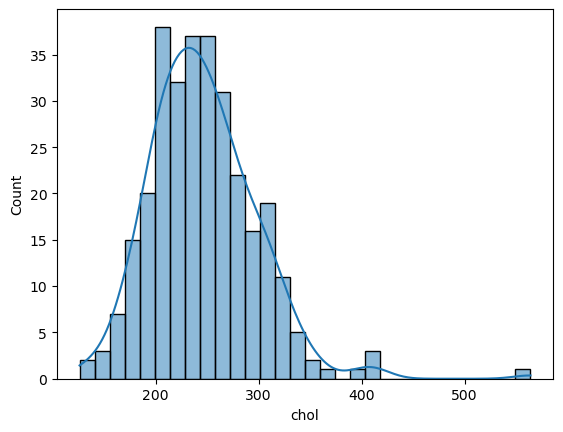

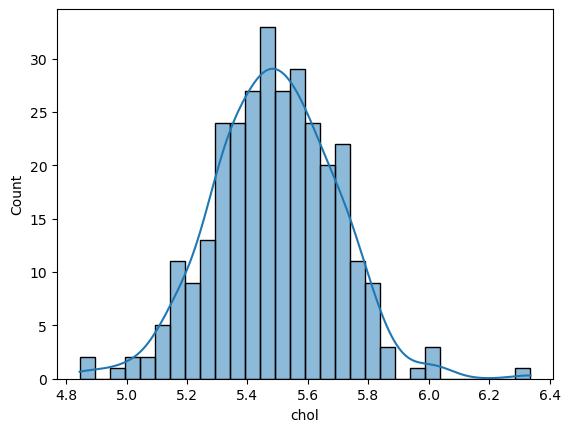

In [13]:
sns.histplot(df["chol"], bins=30, kde=True)
plt.show()

sns.histplot(np.log1p(df["chol"]), bins=30, kde=True)
plt.show()

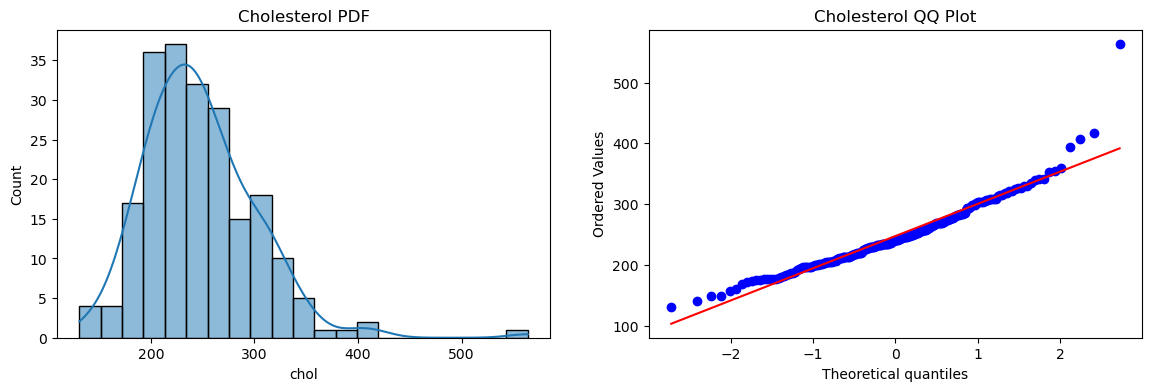

In [17]:
import scipy.stats as stats

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['chol'], kde=True)
plt.title('Cholesterol PDF')

plt.subplot(122)
stats.probplot(X_train['chol'], dist="norm", plot=plt)
plt.title('Cholesterol QQ Plot')

plt.show()